# Study of lyapunov exponents in IFS and AIFS

This notebook aims to study the chaotic behaviour of AIFS, in order to assess whether it would be usable for rare events algorithms. Thus reducing drastically the computing time needed to run them.

The data used is the following:
- IFS Ensemble simulation, each time with a control run and 50 perturbed ensemble predictions.
- AIFS Ensemble simulation, each time with a control run and 50 perturbed ensemble predictions. Note : The AIFS-Diffusion model is used for these outputs by ECMWF, the viability of the AIFS-Deterministic model to be chaotic will be studied too. This notebook is a start until I get access to Jean-Zay GPU cluster to run my own experiments.

The operational IFS EPS samples initial uncertainty using perturbations from an ensemble of data
assimilations (EDA) and perturbations constructed from the leading singular vectors. [From the official documentation](https://www.ecmwf.int/en/elibrary/81627-ifs-documentation-cy49r1-part-v-ensemble-prediction-system)

## Helper functions and packages

In [1]:
# functions

from ensemble_chaos_tools import EnsembleChaos
from ensemble_chaos_tools import fix_lat_lon
import xarray as xr
import glob
import matplotlib.pyplot as plt
import numpy as np
import nicopal as ncp
import cartopy.crs as ccrs

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format="jpeg"

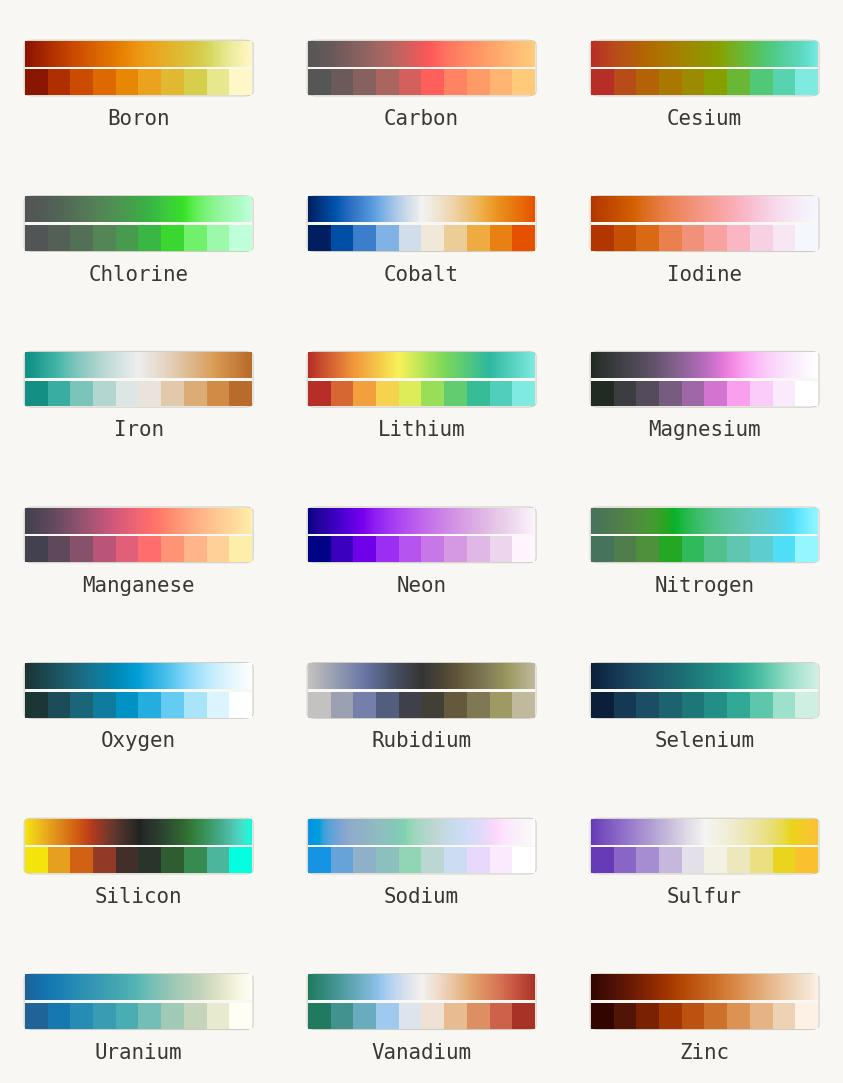

In [65]:
ncp.pal_all()

In [2]:
france_latitude_bnd = slice(42, 51)
france_longitude_bnd = slice(-5, 8)
paris_latitude = 49
paris_longitude = 2.5

bc_latitude_bnd = slice(48, 60)
bc_longitude_bnd = slice(-139, -114)
lytton_latitude = 50.23
lytton_longitude = -121.58

northern_hemisphere_latitude_bnd=slice(0,90)
northern_hemisphere_longitude_bnd=slice(-180,180)

france_centered_latitude_bnd=slice(0,90)
france_centered_longitude_bnd=slice(-60,60)

## Import data

In [3]:
args_import_xr_grib = {"engine": "cfgrib", "decode_timedelta": True}

In [4]:
file_cf_20190723 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2019-07-23.grib"
file_cf_20200724 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2020-07-24.grib"
file_cf_20220706 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2022-07-06.grib"
file_cf_20150622 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2015-06-22.grib"
file_cf_20170621 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2017-06-21.grib"
file_cf_20210617 = (
    "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2021-06-17.grib"  # britain columbia
)
file_cf_20210614 = (
    "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2021-06-14.grib"  # britain columbia
)
file_cf_20250801 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2025-08-01.grib"
file_cf_20251222 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2025-12-22.grib"
file_cf_20210627 = (
    "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2021-06-27.grib"  # britain columbia
)


file_pf_20190723 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2019-07-23.grib"
file_pf_20200724 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2020-07-24.grib"
file_pf_20220706 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2022-07-06.grib"
file_pf_20150622 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2015-06-22.grib"
file_pf_20170621 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2017-06-21.grib"
file_pf_20210617 = (
    "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2021-06-17.grib"  # britain columbia
)
file_pf_20210614 = (
    "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2021-06-14.grib"  # britain columbia
)
file_pf_20250801 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2025-08-01.grib"
file_pf_20251222 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2025-12-22.grib"
file_pf_20210627 = (
    "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2021-06-27.grib"  # britain columbia
)


cf_20150622 = xr.open_dataset(file_cf_20150622, **args_import_xr_grib)
cf_20170621 = xr.open_dataset(file_cf_20170621, **args_import_xr_grib)
cf_20190723 = xr.open_dataset(file_cf_20190723, **args_import_xr_grib)
cf_20200724 = xr.open_dataset(file_cf_20200724, **args_import_xr_grib)
cf_20210614 = xr.open_dataset(file_cf_20210614, **args_import_xr_grib)
cf_20210617 = xr.open_dataset(file_cf_20210617, **args_import_xr_grib)
cf_20220706 = xr.open_dataset(file_cf_20220706, **args_import_xr_grib)
cf_20250801 = xr.open_dataset(file_cf_20250801, **args_import_xr_grib)
cf_20251222 = xr.open_dataset(file_cf_20251222, **args_import_xr_grib)
cf_20210627 = xr.open_dataset(file_cf_20210627, **args_import_xr_grib)


pf_20150622 = xr.open_dataset(file_pf_20150622, **args_import_xr_grib)
pf_20170621 = xr.open_dataset(file_pf_20170621, **args_import_xr_grib)
pf_20190723 = xr.open_dataset(file_pf_20190723, **args_import_xr_grib)
pf_20200724 = xr.open_dataset(file_pf_20200724, **args_import_xr_grib)
pf_20210614 = xr.open_dataset(file_pf_20210614, **args_import_xr_grib)
pf_20210617 = xr.open_dataset(file_pf_20210617, **args_import_xr_grib)
pf_20220706 = xr.open_dataset(file_pf_20220706, **args_import_xr_grib)
pf_20250801 = xr.open_dataset(file_pf_20250801, **args_import_xr_grib)
pf_20251222 = xr.open_dataset(file_pf_20251222, **args_import_xr_grib)
pf_20210627 = xr.open_dataset(file_pf_20210627, **args_import_xr_grib)

In [5]:
pf_aifs_cold_spell_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_pf_20251222.nc", decode_timedelta=True
)
pf_aifs_heat_august_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_pf_20250801.nc", decode_timedelta=True
)
cf_aifs_cold_spell_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_cf_20251222.nc", decode_timedelta=True
).assign_coords(number=0)
cf_aifs_heat_august_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_cf_20250801.nc", decode_timedelta=True
).assign_coords(number=0)

Creating the objects

In [6]:
chaos_ifs_20150622 = EnsembleChaos(cf_20150622, pf_20150622)
chaos_ifs_20170621 = EnsembleChaos(cf_20170621, pf_20170621)
chaos_ifs_20190723 = EnsembleChaos(cf_20190723, pf_20190723)
chaos_ifs_20200724 = EnsembleChaos(cf_20200724, pf_20200724)
chaos_ifs_20220706 = EnsembleChaos(cf_20220706, pf_20220706)
chaos_ifs_heat_august_2025 = EnsembleChaos(cf_20250801, pf_20250801)
chaos_ifs_cold_spell_2025 = EnsembleChaos(cf_20251222, pf_20251222)
chaos_ifs_20210614 = EnsembleChaos(cf_20210614, pf_20210614) #bc
chaos_ifs_20210617 = EnsembleChaos(cf_20210617, pf_20210617) #bc
chaos_ifs_20210627 = EnsembleChaos(cf_20210627, pf_20210627) #bc

chaos_aifs_cold_spell_2025 = EnsembleChaos(cf_aifs_cold_spell_2025, pf_aifs_cold_spell_2025)
chaos_aifs_heat_august_2025 = EnsembleChaos(cf_aifs_heat_august_2025, pf_aifs_heat_august_2025)

## Plot trajectories

### At a single point

#### Only IFS

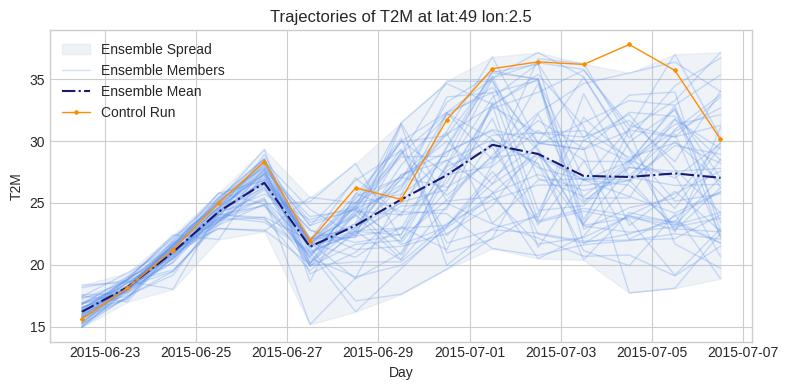

In [7]:
chaos_ifs_20150622.plot_trajectories_on_single_point(paris_latitude,paris_longitude,[12])

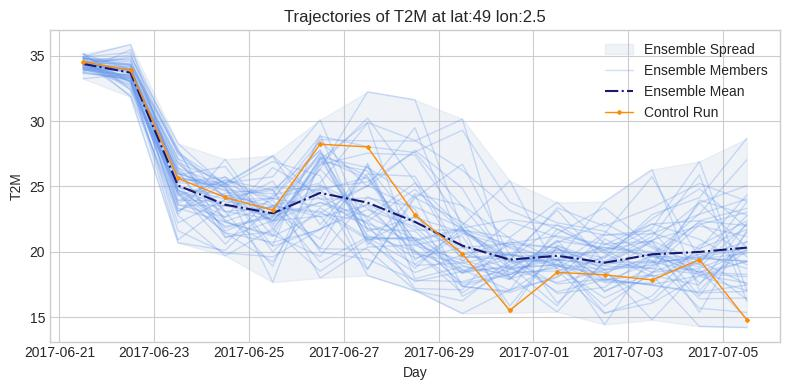

In [8]:
chaos_ifs_20170621.plot_trajectories_on_single_point(paris_latitude,paris_longitude,[12])

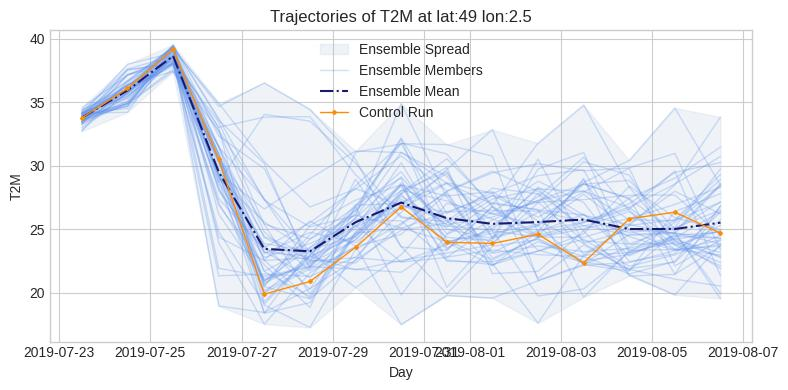

In [9]:
chaos_ifs_20190723.plot_trajectories_on_single_point(paris_latitude,paris_longitude,[12])

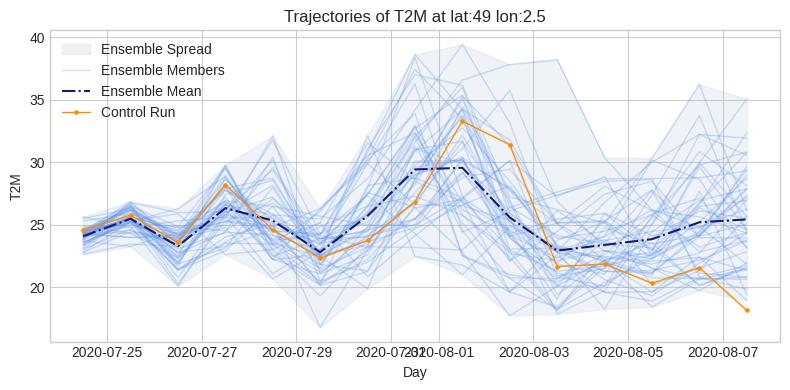

In [10]:
chaos_ifs_20200724.plot_trajectories_on_single_point(paris_latitude,paris_longitude,[12])

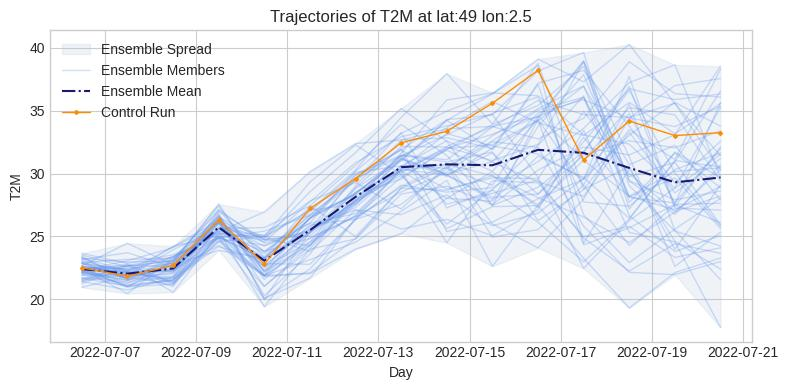

In [11]:
chaos_ifs_20220706.plot_trajectories_on_single_point(paris_latitude,paris_longitude,[12])

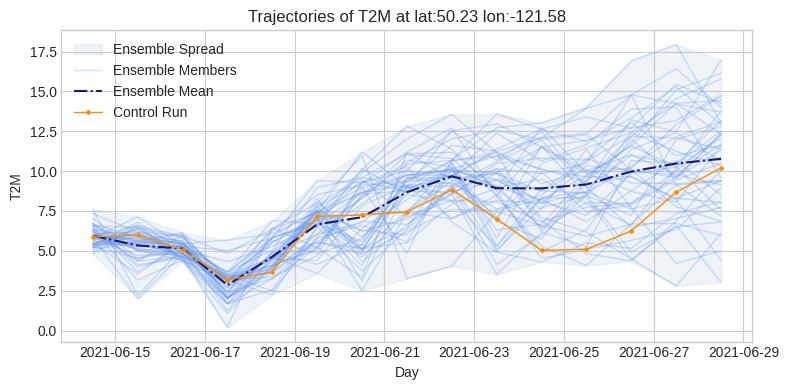

In [12]:
chaos_ifs_20210614.plot_trajectories_on_single_point(lytton_latitude,lytton_longitude,[12])

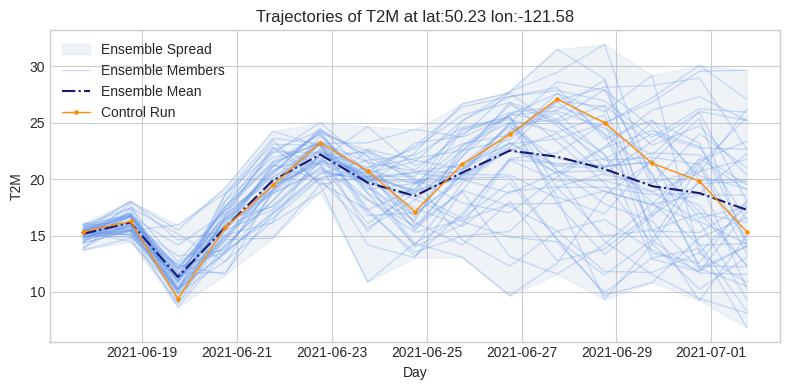

In [13]:
chaos_ifs_20210617.plot_trajectories_on_single_point(lytton_latitude,lytton_longitude,[18])

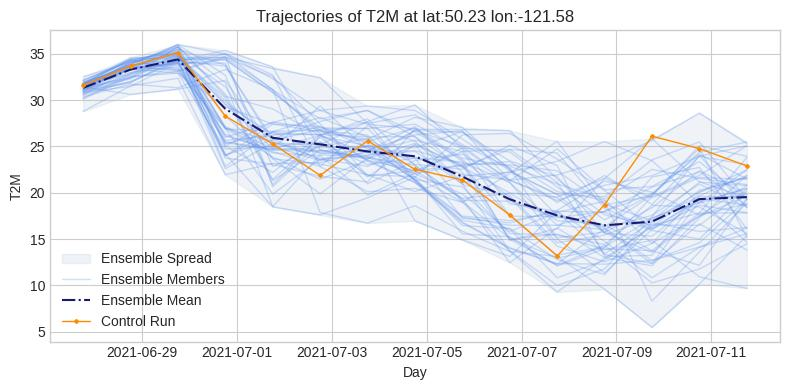

In [14]:
chaos_ifs_20210627.plot_trajectories_on_single_point(lytton_latitude,lytton_longitude,[18])

#### IFS and AIFS

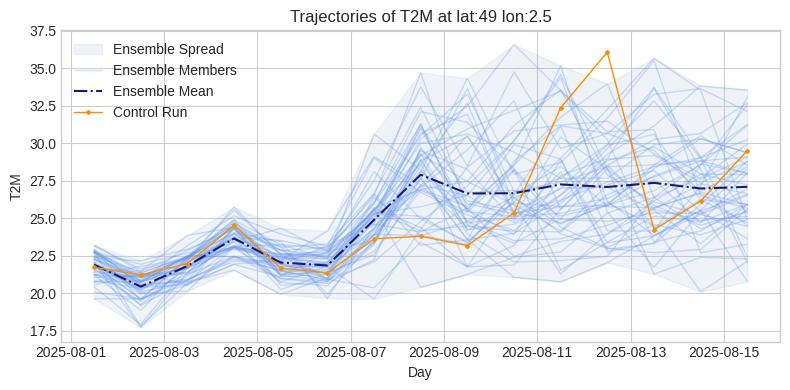

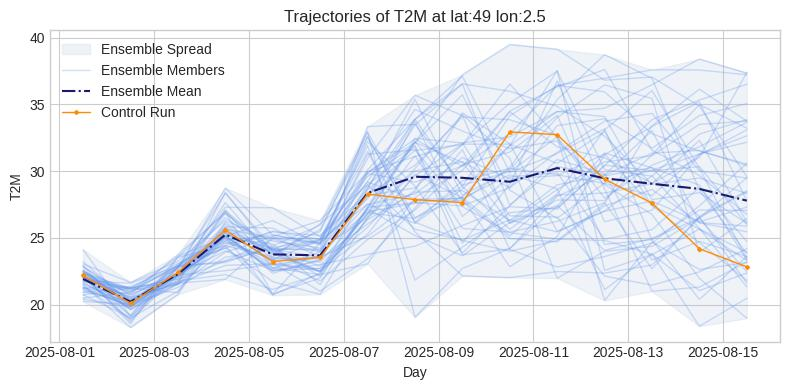

In [15]:
chaos_ifs_heat_august_2025.plot_trajectories_on_single_point(paris_latitude,paris_longitude,[12])
chaos_aifs_heat_august_2025.plot_trajectories_on_single_point(paris_latitude,paris_longitude,[12])

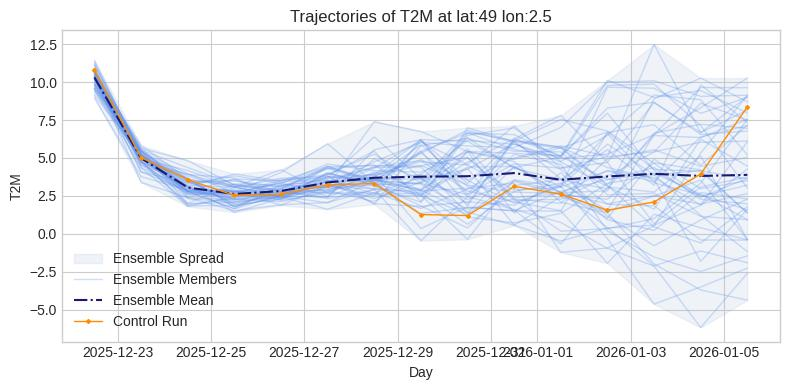

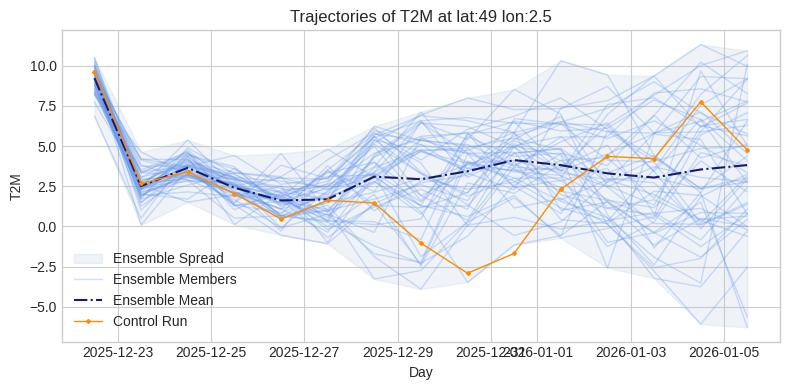

In [16]:
chaos_ifs_cold_spell_2025.plot_trajectories_on_single_point(paris_latitude,paris_longitude,[12])
chaos_aifs_cold_spell_2025.plot_trajectories_on_single_point(paris_latitude,paris_longitude,[12])

### Over an area

#### Only IFS

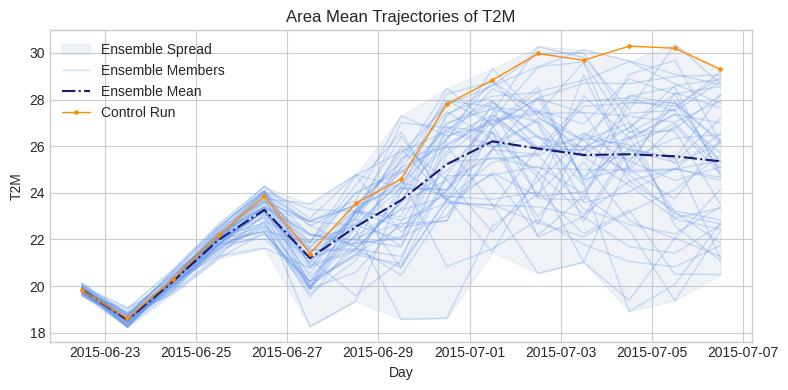

In [17]:
chaos_ifs_20150622.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])

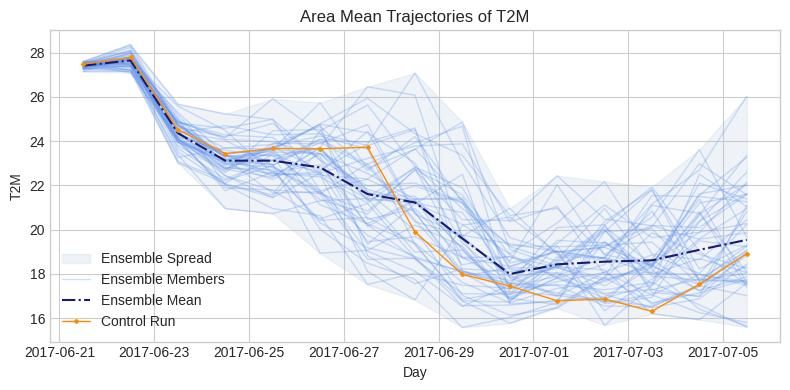

In [18]:
chaos_ifs_20170621.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])

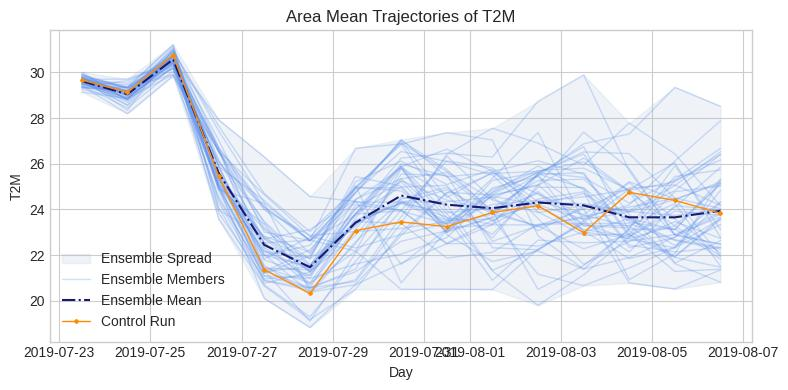

In [21]:
chaos_ifs_20190723.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])

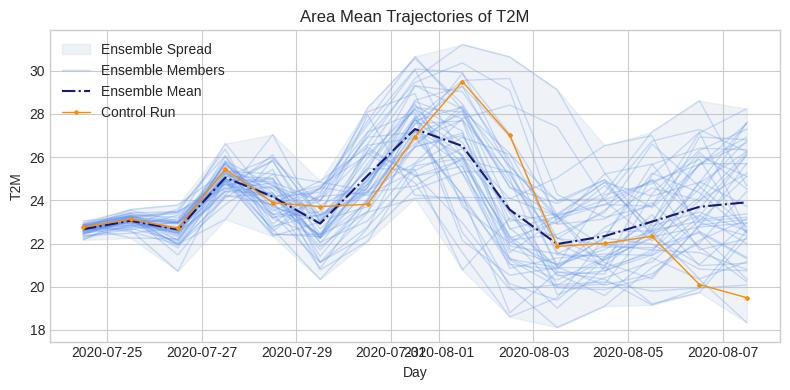

In [22]:
chaos_ifs_20200724.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])

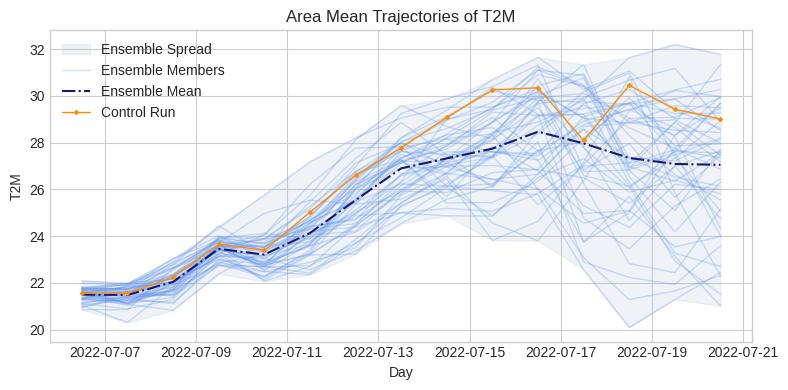

In [23]:
chaos_ifs_20220706.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])

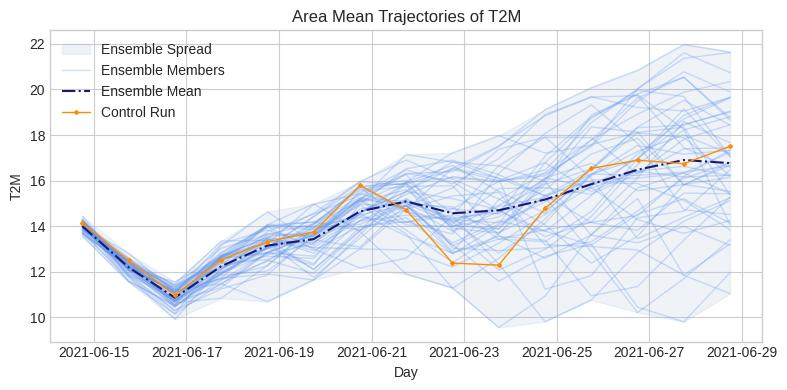

In [25]:
chaos_ifs_20210614.plot_trajectories_on_area_mean(bc_latitude_bnd,bc_longitude_bnd,[18])

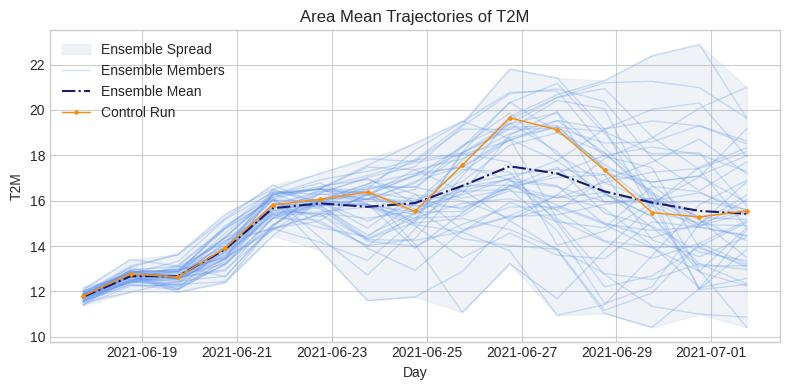

In [26]:
chaos_ifs_20210617.plot_trajectories_on_area_mean(bc_latitude_bnd,bc_longitude_bnd,[18])

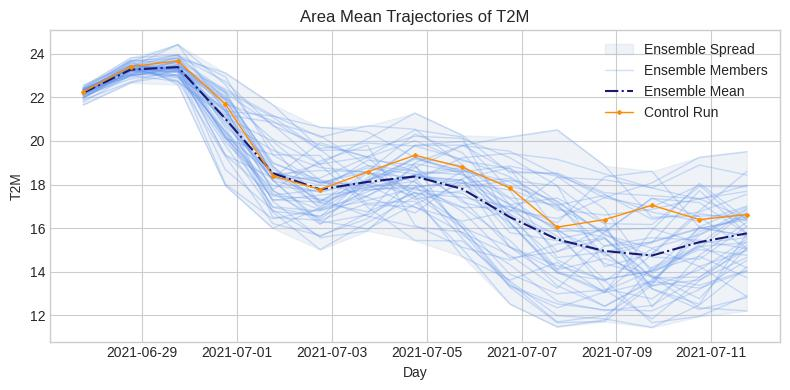

In [27]:
chaos_ifs_20210627.plot_trajectories_on_area_mean(bc_latitude_bnd,bc_longitude_bnd,[18])

#### IFS and AIFS

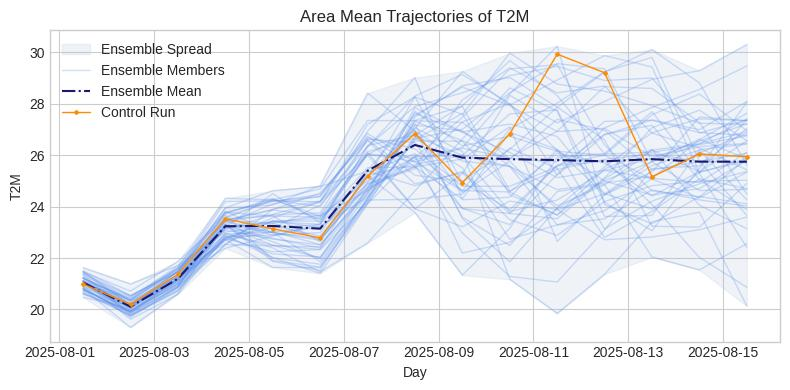

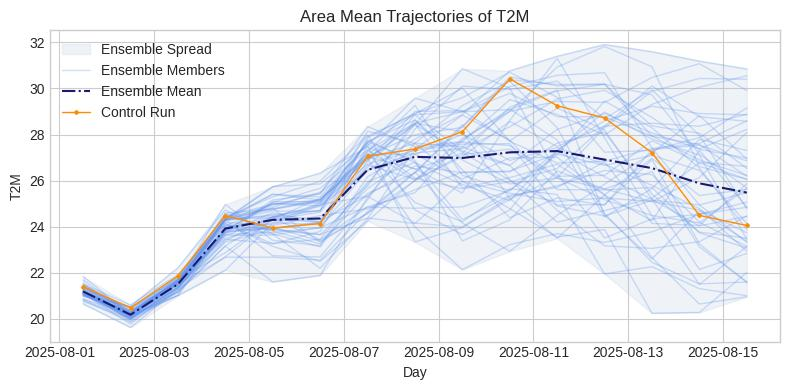

In [28]:
chaos_ifs_heat_august_2025.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])
chaos_aifs_heat_august_2025.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])

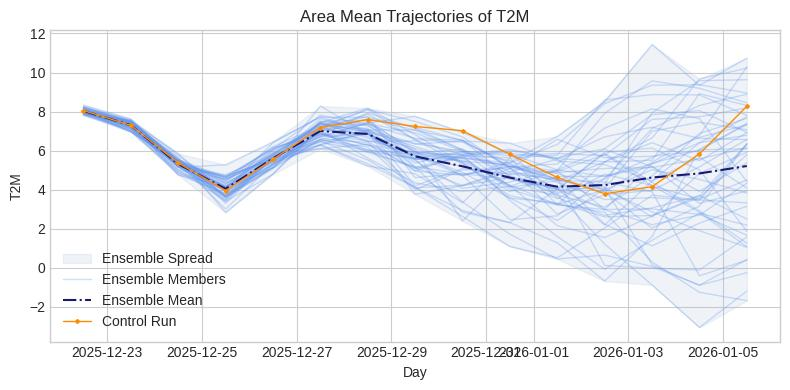

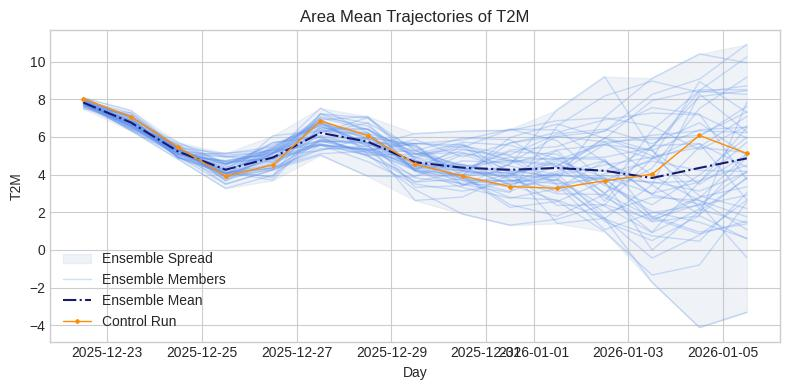

In [30]:
chaos_ifs_cold_spell_2025.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])
chaos_aifs_cold_spell_2025.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])

## Compute Lyapunov Exponents (Growth Rates)

### At a single point

#### Only IFS

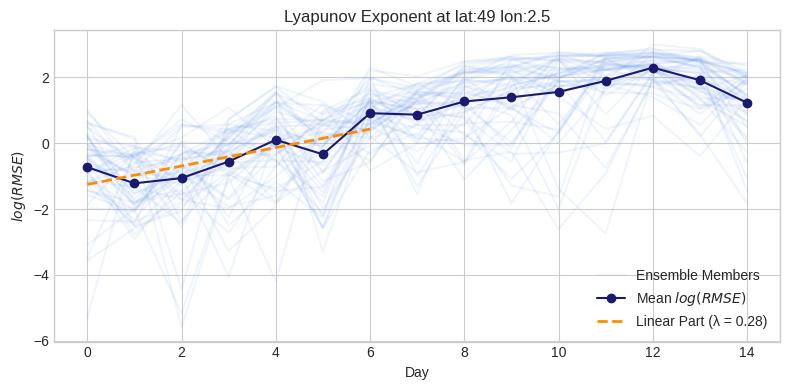

Estimated Lyapunov Exponent (λ): 0.28 days^-1


In [32]:
chaos_ifs_20150622.lyapunov_single_point(paris_latitude,paris_longitude,[12])

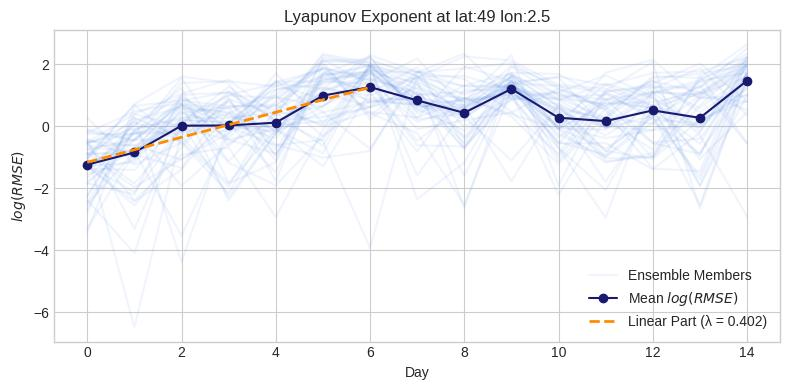

Estimated Lyapunov Exponent (λ): 0.402 days^-1


In [33]:
chaos_ifs_20170621.lyapunov_single_point(paris_latitude,paris_longitude,[12])

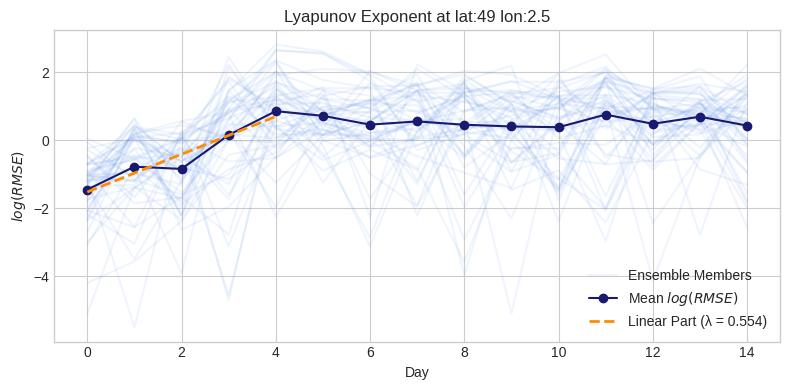

Estimated Lyapunov Exponent (λ): 0.554 days^-1


In [34]:
chaos_ifs_20190723.lyapunov_single_point(paris_latitude,paris_longitude,[12])

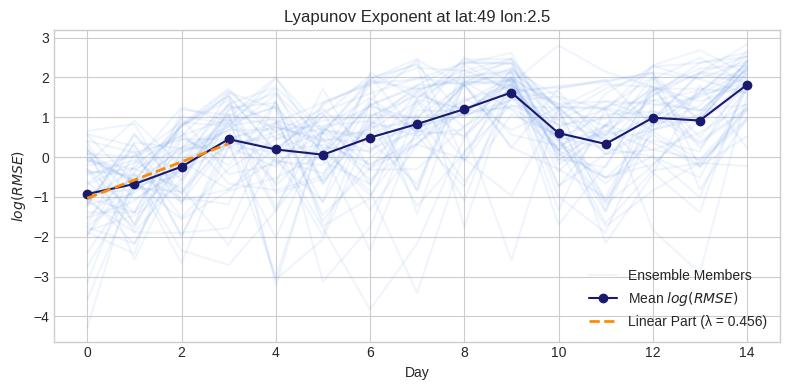

Estimated Lyapunov Exponent (λ): 0.456 days^-1


In [35]:
chaos_ifs_20200724.lyapunov_single_point(paris_latitude,paris_longitude,[12])

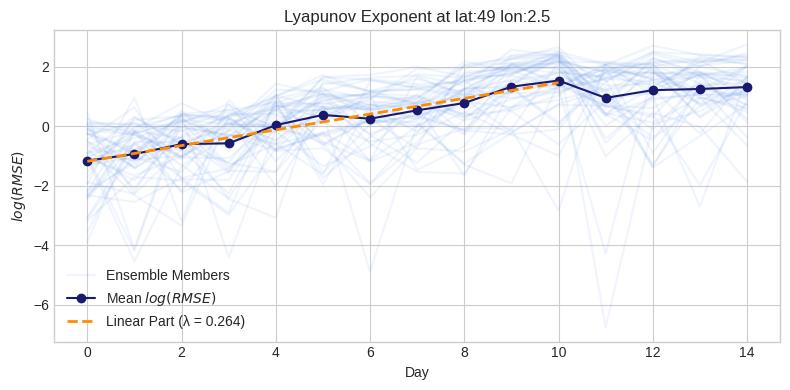

Estimated Lyapunov Exponent (λ): 0.264 days^-1


In [36]:
chaos_ifs_20220706.lyapunov_single_point(paris_latitude,paris_longitude,[12])

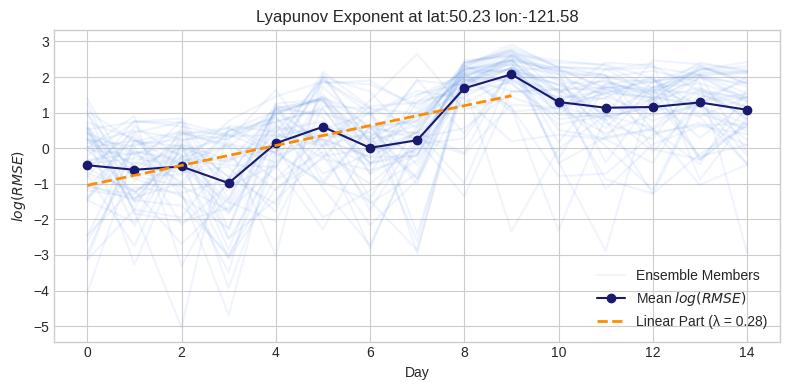

Estimated Lyapunov Exponent (λ): 0.28 days^-1


In [37]:
chaos_ifs_20210614.lyapunov_single_point(lytton_latitude,lytton_longitude,[18])

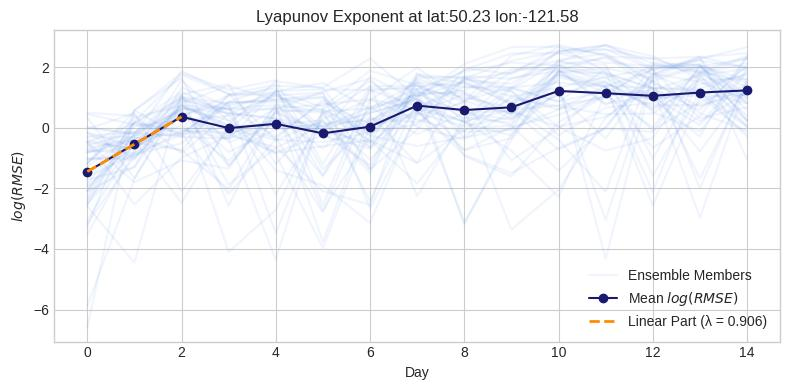

Estimated Lyapunov Exponent (λ): 0.906 days^-1


In [38]:
chaos_ifs_20210617.lyapunov_single_point(lytton_latitude,lytton_longitude,[18])

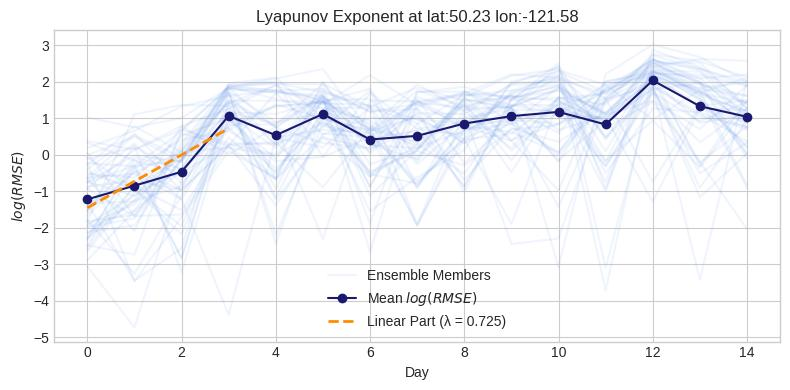

Estimated Lyapunov Exponent (λ): 0.725 days^-1


In [39]:
chaos_ifs_20210627.lyapunov_single_point(lytton_latitude,lytton_longitude,[18])

#### IFS and AIFS

In [ ]:
chaos_ifs_heat_august_2025.lyapunov_single_point(paris_latitude,paris_longitude,[12])
chaos_aifs_heat_august_2025.lyapunov_single_point(paris_latitude,paris_longitude,[12])

In [ ]:
chaos_ifs_cold_spell_2025.lyapunov_single_point(paris_latitude,paris_longitude,[12])
chaos_aifs_cold_spell_2025.lyapunov_single_point(paris_latitude,paris_longitude,[12])

### Over an area

#### Only IFS

In [ ]:
chaos_ifs_20150622.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd,[12])

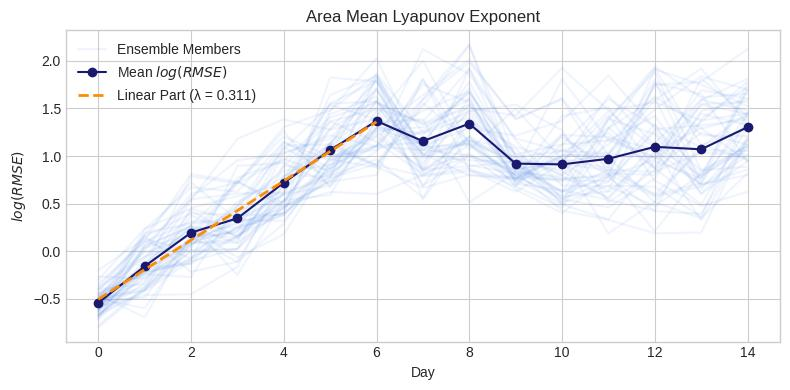

Estimated Lyapunov Exponent (λ): 0.311 days^-1


np.float64(0.311)

In [40]:
chaos_ifs_20170621.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd,[12])

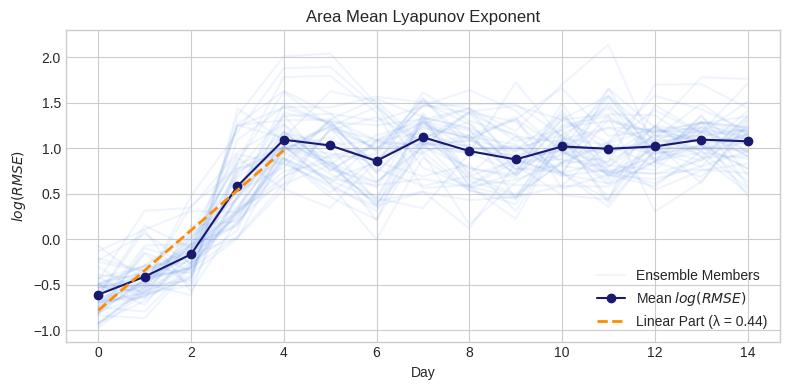

Estimated Lyapunov Exponent (λ): 0.44 days^-1


np.float64(0.44)

In [41]:
chaos_ifs_20190723.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd,[12])

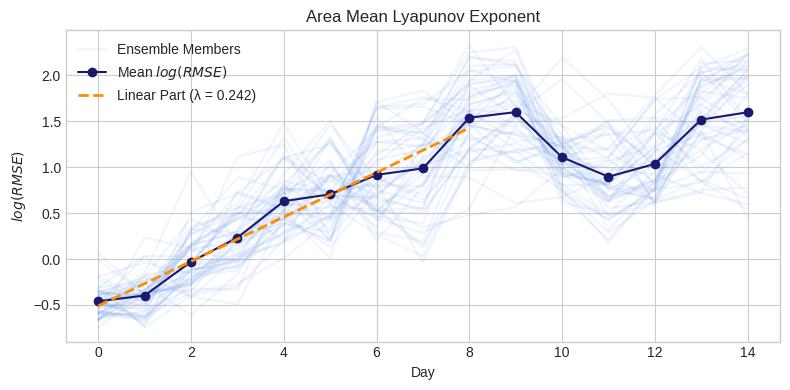

Estimated Lyapunov Exponent (λ): 0.242 days^-1


np.float64(0.242)

In [42]:
chaos_ifs_20200724.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd,[12])

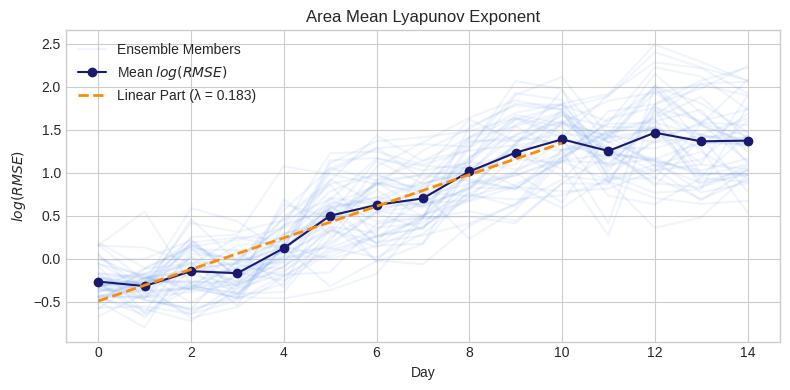

Estimated Lyapunov Exponent (λ): 0.183 days^-1


np.float64(0.183)

In [43]:
chaos_ifs_20220706.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd,[12])

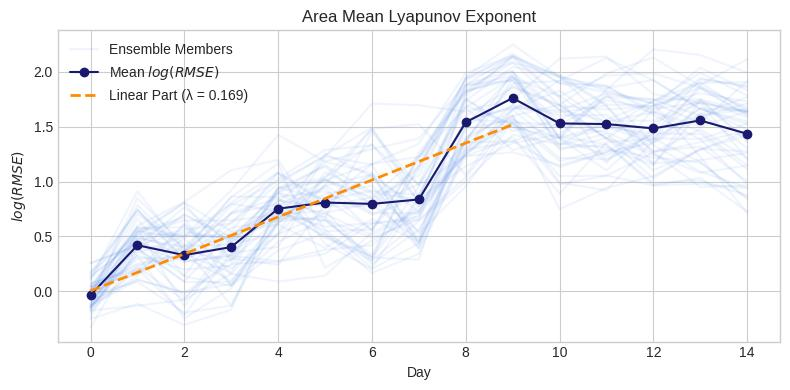

Estimated Lyapunov Exponent (λ): 0.169 days^-1


np.float64(0.169)

In [44]:
chaos_ifs_20210614.lyapunov_over_area(bc_latitude_bnd,bc_longitude_bnd,[18])

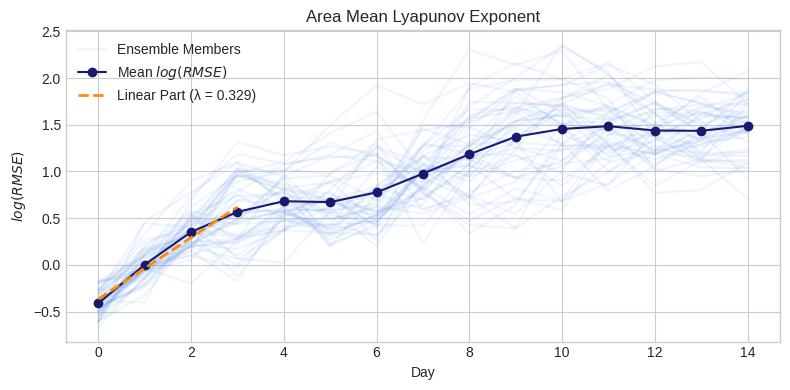

Estimated Lyapunov Exponent (λ): 0.329 days^-1


np.float64(0.329)

In [45]:
chaos_ifs_20210617.lyapunov_over_area(bc_latitude_bnd,bc_longitude_bnd,[18])

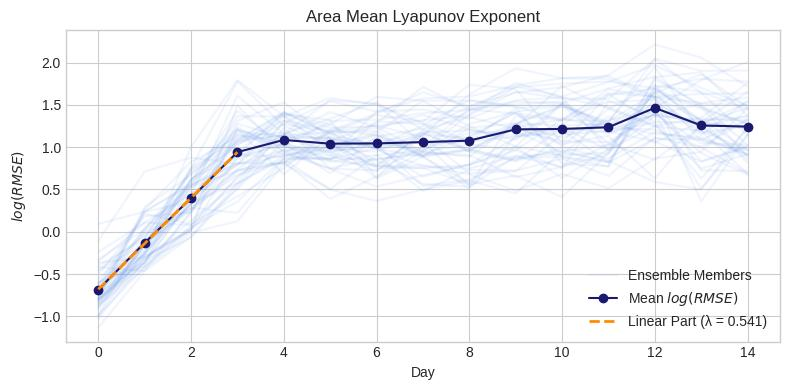

Estimated Lyapunov Exponent (λ): 0.541 days^-1


np.float64(0.541)

In [46]:
chaos_ifs_20210627.lyapunov_over_area(bc_latitude_bnd,bc_longitude_bnd,[18])

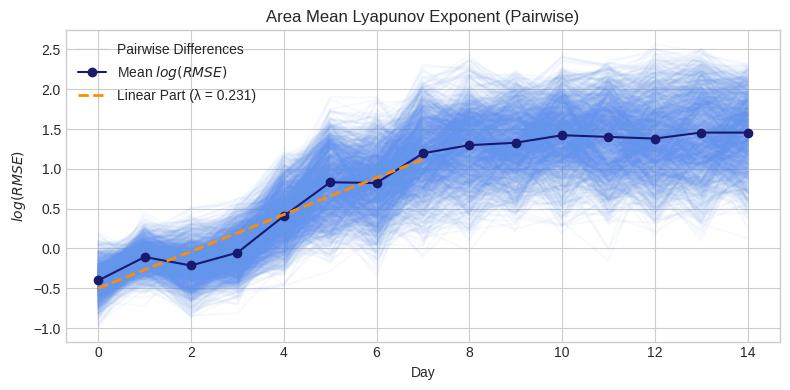

Estimated Lyapunov Exponent (λ): 0.231 days^-1


np.float64(0.231)

In [47]:
chaos_ifs_20150622.lyapunov_over_area_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

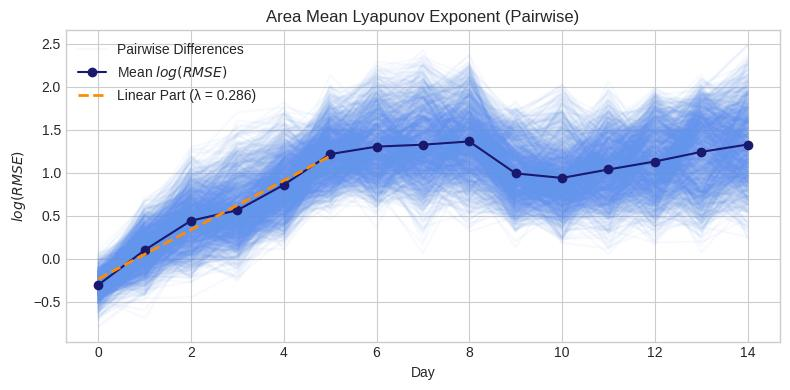

Estimated Lyapunov Exponent (λ): 0.286 days^-1


np.float64(0.286)

In [48]:
chaos_ifs_20170621.lyapunov_over_area_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

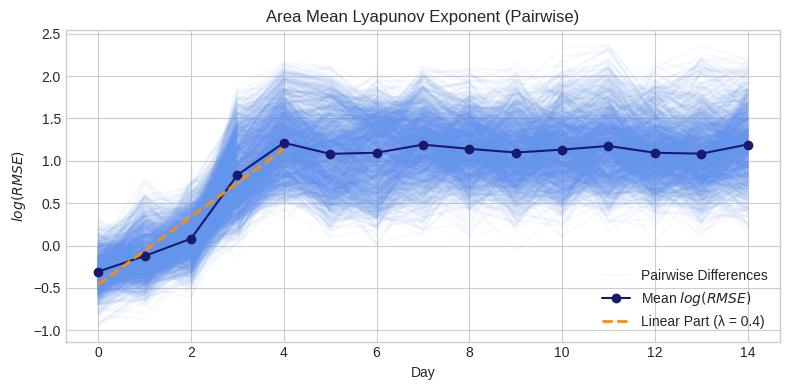

Estimated Lyapunov Exponent (λ): 0.4 days^-1


np.float64(0.4)

In [49]:
chaos_ifs_20190723.lyapunov_over_area_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

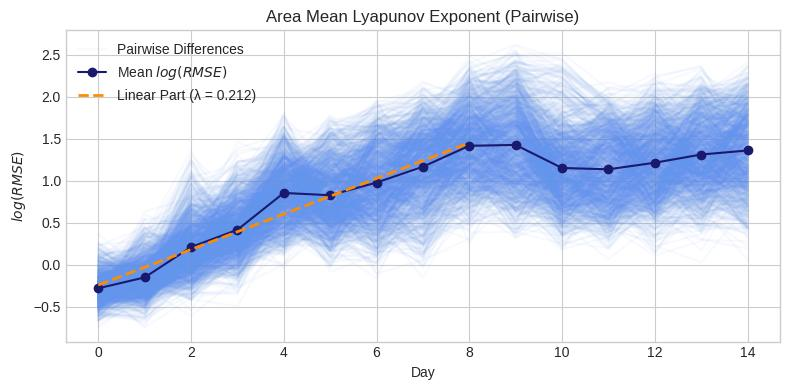

Estimated Lyapunov Exponent (λ): 0.212 days^-1


np.float64(0.212)

In [50]:
chaos_ifs_20200724.lyapunov_over_area_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

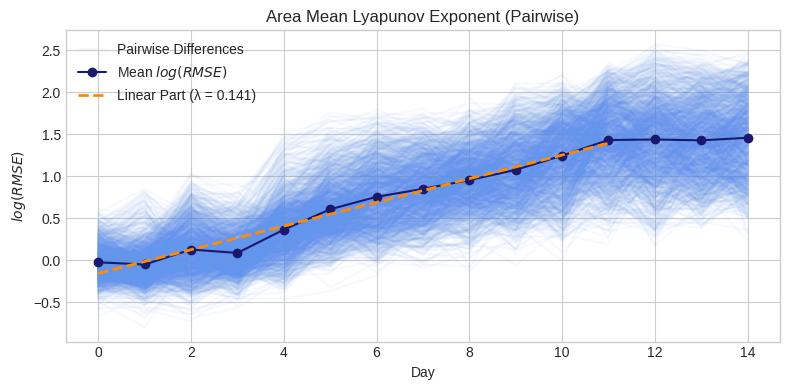

Estimated Lyapunov Exponent (λ): 0.141 days^-1


np.float64(0.141)

In [51]:
chaos_ifs_20220706.lyapunov_over_area_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

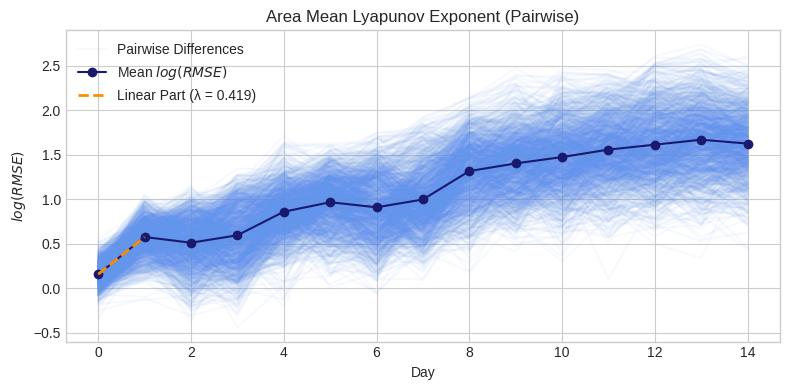

Estimated Lyapunov Exponent (λ): 0.419 days^-1


np.float64(0.419)

In [52]:
chaos_ifs_20210614.lyapunov_over_area_pairwise(bc_latitude_bnd,bc_longitude_bnd,[18])

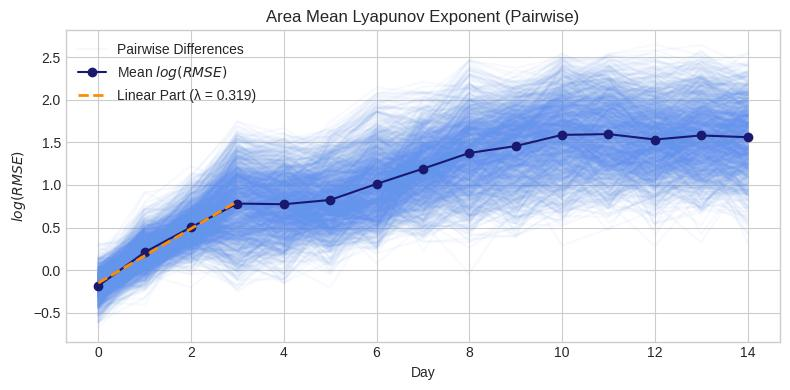

Estimated Lyapunov Exponent (λ): 0.319 days^-1


np.float64(0.319)

In [53]:
chaos_ifs_20210617.lyapunov_over_area_pairwise(bc_latitude_bnd,bc_longitude_bnd,[18])

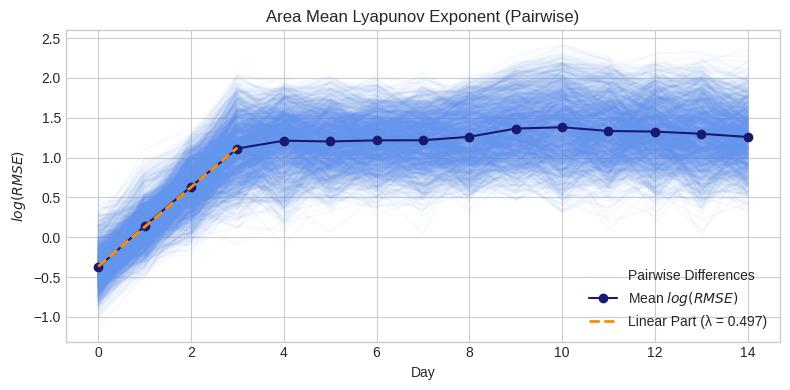

Estimated Lyapunov Exponent (λ): 0.497 days^-1


np.float64(0.497)

In [54]:
chaos_ifs_20210627.lyapunov_over_area_pairwise(bc_latitude_bnd,bc_longitude_bnd,[18])

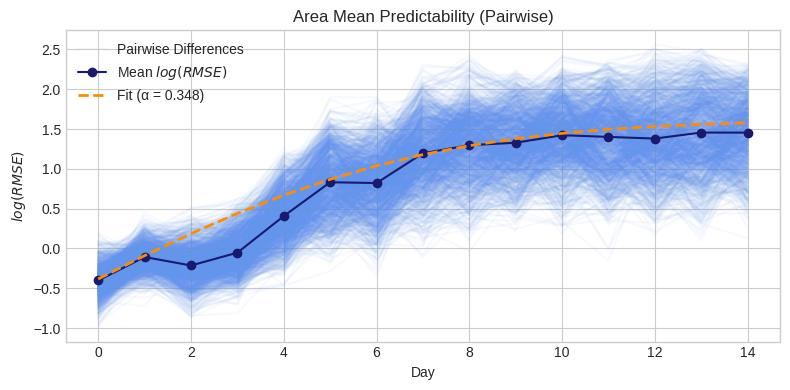

Estimated Growth Rate (α): 0.348 days^-1 | Saturation Error (E_inf): 5.093


(np.float64(0.348), np.float64(5.093))

In [55]:
chaos_ifs_20150622.growth_rate_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

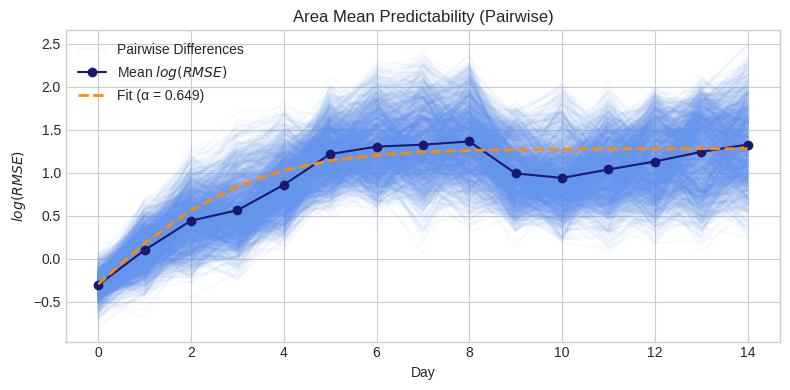

Estimated Growth Rate (α): 0.649 days^-1 | Saturation Error (E_inf): 3.591


(np.float64(0.649), np.float64(3.591))

In [56]:
chaos_ifs_20170621.growth_rate_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

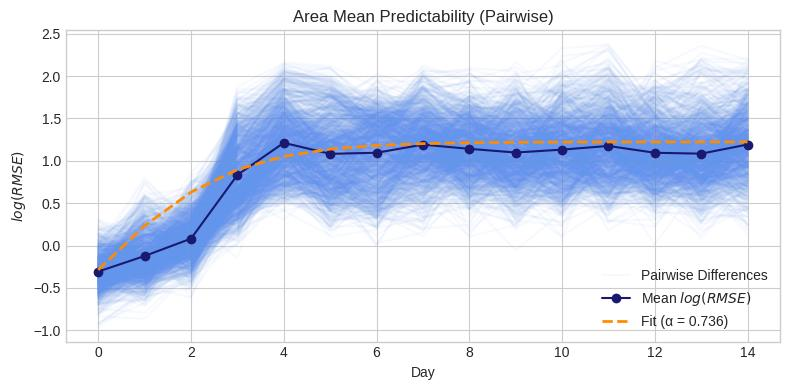

Estimated Growth Rate (α): 0.736 days^-1 | Saturation Error (E_inf): 3.399


(np.float64(0.736), np.float64(3.399))

In [57]:
chaos_ifs_20190723.growth_rate_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

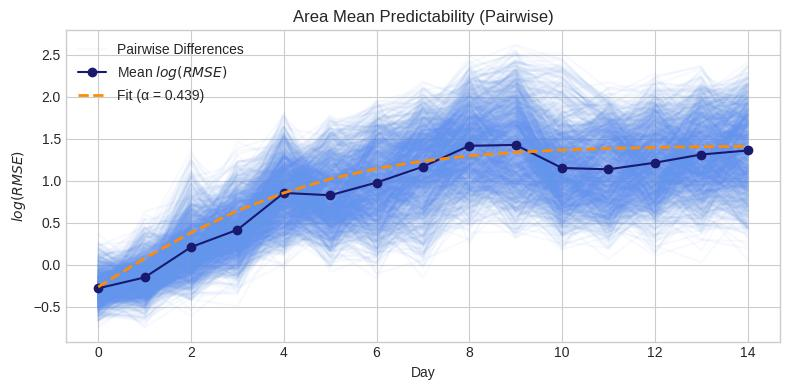

Estimated Growth Rate (α): 0.439 days^-1 | Saturation Error (E_inf): 4.143


(np.float64(0.439), np.float64(4.143))

In [58]:
chaos_ifs_20200724.growth_rate_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

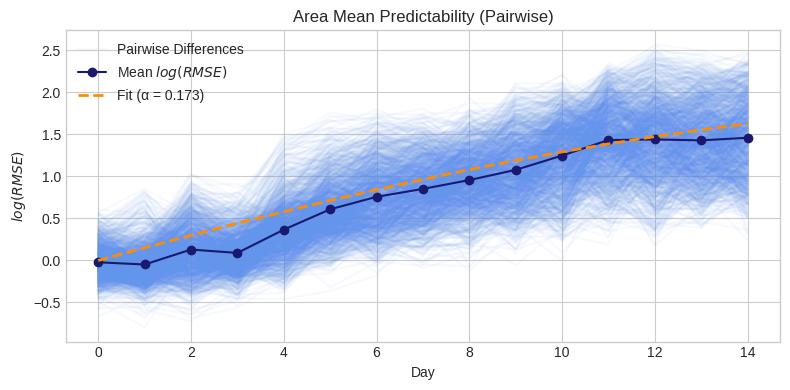

Estimated Growth Rate (α): 0.173 days^-1 | Saturation Error (E_inf): 8.452


(np.float64(0.173), np.float64(8.452))

In [59]:
chaos_ifs_20220706.growth_rate_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

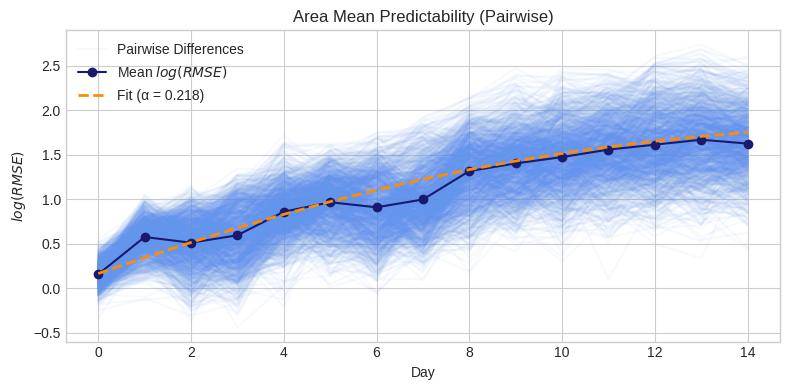

Estimated Growth Rate (α): 0.218 days^-1 | Saturation Error (E_inf): 7.14


(np.float64(0.218), np.float64(7.14))

In [60]:
chaos_ifs_20210614.growth_rate_pairwise(bc_latitude_bnd,bc_longitude_bnd,[18])

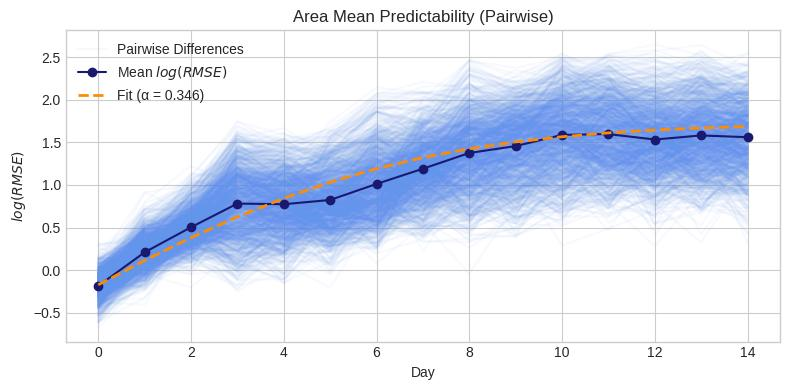

Estimated Growth Rate (α): 0.346 days^-1 | Saturation Error (E_inf): 5.642


(np.float64(0.346), np.float64(5.642))

In [61]:
chaos_ifs_20210617.growth_rate_pairwise(bc_latitude_bnd,bc_longitude_bnd,[18])

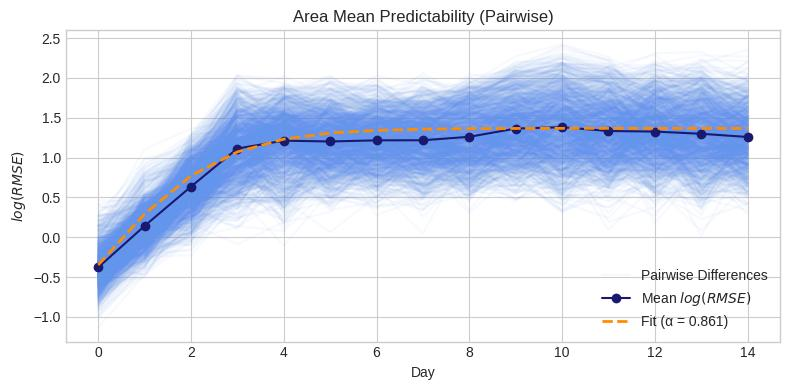

Estimated Growth Rate (α): 0.861 days^-1 | Saturation Error (E_inf): 3.928


(np.float64(0.861), np.float64(3.928))

In [62]:
chaos_ifs_20210627.growth_rate_pairwise(bc_latitude_bnd,bc_longitude_bnd,[18])

#### IFS and AIFS

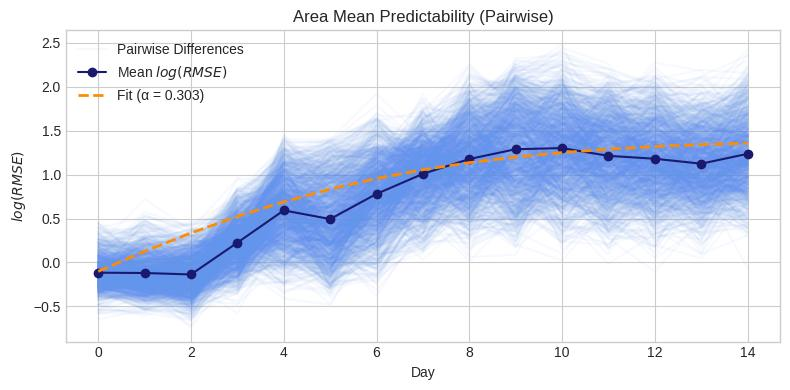

Estimated Growth Rate (α): 0.303 days^-1 | Saturation Error (E_inf): 4.089


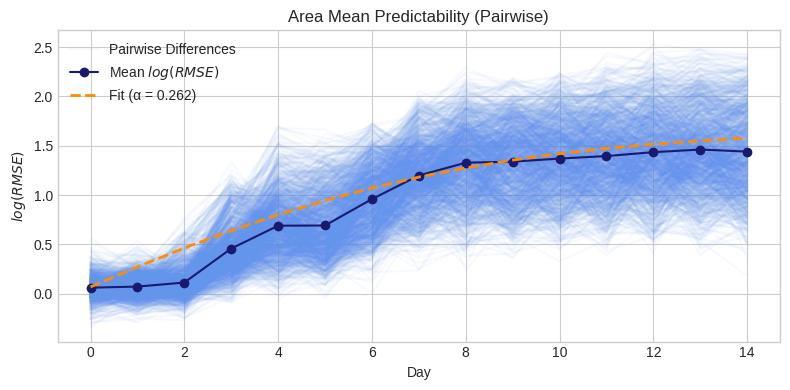

Estimated Growth Rate (α): 0.262 days^-1 | Saturation Error (E_inf): 5.333


(np.float64(0.262), np.float64(5.333))

In [63]:
chaos_ifs_heat_august_2025.growth_rate_pairwise(france_latitude_bnd,france_longitude_bnd,[12])
chaos_aifs_heat_august_2025.growth_rate_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

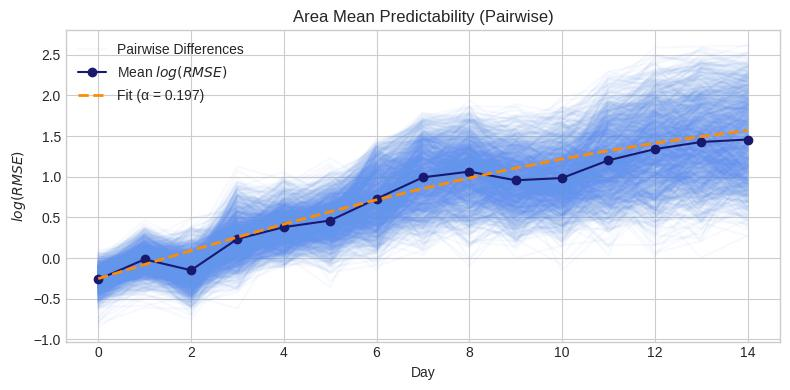

Estimated Growth Rate (α): 0.197 days^-1 | Saturation Error (E_inf): 7.391


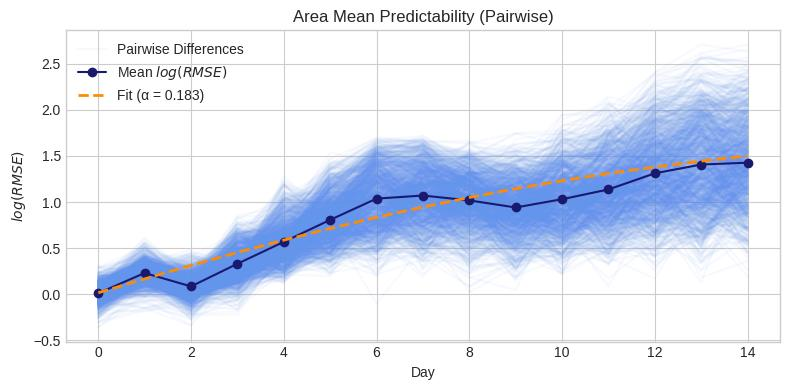

Estimated Growth Rate (α): 0.183 days^-1 | Saturation Error (E_inf): 6.272


(np.float64(0.183), np.float64(6.272))

In [64]:
chaos_ifs_cold_spell_2025.growth_rate_pairwise(france_latitude_bnd,france_longitude_bnd,[12])
chaos_aifs_cold_spell_2025.growth_rate_pairwise(france_latitude_bnd,france_longitude_bnd,[12])

# Plot some maps

In [ ]:
chaos_ifs_heat_august_2025.plot_nice_looking_animation(france_latitude_bnd, france_longitude_bnd,filename="test1.gif")

In [ ]:
chaos_ifs_heat_august_2025.plot_nice_looking_animation_ortho(france_latitude_bnd, france_longitude_bnd,filename="test2.gif")